In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("../data/raw/customers_data.csv")
marketing = pd.read_csv("../data/raw/marketing_data.csv")
products = pd.read_csv("../data/raw/products_data.csv")
sales = pd.read_csv("../data/raw/sales_data.csv")

In [4]:
#Vérifier les dimensions:
print("Customers :", customers.shape)
print("Marketing :", marketing.shape)
print("Products  :", products.shape)
print("Sales     :", sales.shape)

Customers : (5, 7)
Marketing : (5, 8)
Products  : (5, 5)
Sales     : (5, 7)


In [5]:
#Afficher:
display(customers.head())
display(marketing.head())
display(products.head())
display(sales.head())

,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent
0,2001,Alice,28,Female,New York,2022-05-10,500.0
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0


,Campaign_ID,Channel,Start_Date,End_Date,Budget,Impressions,Clicks,Conversions
0,1,Online,2023-01-01,2023-01-15,1000.0,50000,2000,150
1,2,In-Store,2023-01-10,2023-01-20,1500.0,30000,500,100
2,3,Social,2023-01-15,2023-01-25,2000.0,40000,1500,200
3,4,Email,2023-01-05,2023-01-15,500.0,20000,1000,50
4,5,TV,2023-01-01,2023-01-31,3000.0,60000,3000,250


,Product_ID,Product_Name,Category,Price,Brand
0,101,T-shirt,Clothing,25.0,Brand A
1,102,Jeans,Clothing,75.0,Brand B
2,103,Sneakers,Footwear,30.0,Brand C
3,104,Jacket,Outerwear,120.0,Brand D
4,105,Hat,Accessories,22.5,Brand E


,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel
0,1,101,2001,2023-01-15,2,50.0,Online
1,2,102,2002,2023-01-16,1,75.0,In-Store
2,3,103,2001,2023-01-17,3,30.0,Online
3,4,104,2003,2023-01-18,1,120.0,In-Store
4,5,105,2004,2023-01-19,2,45.0,Online


In [4]:
#Types:
customers.info()
marketing.info()
products.info()
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  5 non-null      int64  
 1   Name         5 non-null      str    
 2   Age          5 non-null      int64  
 3   Gender       5 non-null      str    
 4   Location     5 non-null      str    
 5   Join_Date    5 non-null      str    
 6   Total_Spent  5 non-null      float64
dtypes: float64(1), int64(2), str(4)
memory usage: 551.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Campaign_ID  5 non-null      int64  
 1   Channel      5 non-null      str    
 2   Start_Date   5 non-null      str    
 3   End_Date     5 non-null      str    
 4   Budget       5 non-null      float64
 5   Impressions  5 non-null      int64  
 6   Clicks       5 non-null      int64  
 7 

In [9]:
#Valeurs maquantes:
print(customers.isnull().sum())
print(marketing.isnull().sum())
print(products.isnull().sum())
print(sales.isnull().sum())

Customer_ID    0
Name           0
Age            0
Gender         0
Location       0
Join_Date      0
Total_Spent    0
dtype: int64
Campaign_ID    0
Channel        0
Start_Date     0
End_Date       0
Budget         0
Impressions    0
Clicks         0
Conversions    0
dtype: int64
Product_ID      0
Product_Name    0
Category        0
Price           0
Brand           0
dtype: int64
Sale_ID        0
Product_ID     0
Customer_ID    0
Date           0
Quantity       0
Sale_Price     0
Channel        0
Revenue        0
dtype: int64


In [10]:
#Doublons:
print("Customers :", customers.duplicated().sum())
print("Marketing :", marketing.duplicated().sum())
print("Products :", products.duplicated().sum())
print("Sales :", sales.duplicated().sum())

Customers : 0
Marketing : 0
Products : 0
Sales : 0


In [ ]:
#Nettoyage + fusion des données

In [12]:
#Convertir les dates :
customers["Join_Date"] = pd.to_datetime(customers["Join_Date"])
marketing["Start_Date"] = pd.to_datetime(marketing["Start_Date"])
marketing["End_Date"] = pd.to_datetime(marketing["End_Date"])
sales["Date"] = pd.to_datetime(sales["Date"])

In [13]:
#Calculer le revenu de chaque vente :
sales["Revenue"] = sales["Quantity"] * sales["Sale_Price"]

In [14]:
#Fusion Sales + Customers
sales_full = sales.merge(
    customers,
    on="Customer_ID",
    how="left"
)

In [15]:
#Ajouter les produits
sales_full = sales_full.merge(
    products,
    on="Product_ID",
    how="left"
)

In [16]:
#Vérifier :
display(sales_full)

,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel,Revenue,Name,Age,Gender,Location,Join_Date,Total_Spent,Product_Name,Category,Price,Brand
0,1,101,2001,2023-01-15,2,50.0,Online,100.0,Alice,28,Female,New York,2022-05-10,500.0,T-shirt,Clothing,25.0,Brand A
1,2,102,2002,2023-01-16,1,75.0,In-Store,75.0,Bob,35,Male,Los Angeles,2022-06-15,750.0,Jeans,Clothing,75.0,Brand B
2,3,103,2001,2023-01-17,3,30.0,Online,90.0,Alice,28,Female,New York,2022-05-10,500.0,Sneakers,Footwear,30.0,Brand C
3,4,104,2003,2023-01-18,1,120.0,In-Store,120.0,Charlie,22,Male,Chicago,2022-07-20,300.0,Jacket,Outerwear,120.0,Brand D
4,5,105,2004,2023-01-19,2,45.0,Online,90.0,Diana,30,Female,Houston,2022-08-25,600.0,Hat,Accessories,22.5,Brand E


In [17]:
#Sauvegarder :
sales_full.to_csv(
    "../data/processed/sales_full.csv",
    index=False
)

In [18]:
#Analyse exploratoire EDA

In [19]:
#Statistiques clients
customers.describe()

,Customer_ID,Age,Join_Date,Total_Spent
count,5.000000,5.000000,5,5.000000
mean,2003.000000,28.400000,2022-07-20 09:36:00,520.000000
min,2001.000000,22.000000,2022-05-10 00:00:00,300.000000
25%,2002.000000,27.000000,2022-06-15 00:00:00,450.000000
50%,2003.000000,28.000000,2022-07-20 00:00:00,500.000000
75%,2004.000000,30.000000,2022-08-25 00:00:00,600.000000
max,2005.000000,35.000000,2022-09-30 00:00:00,750.000000
std,1.581139,4.722288,NaN,168.077363


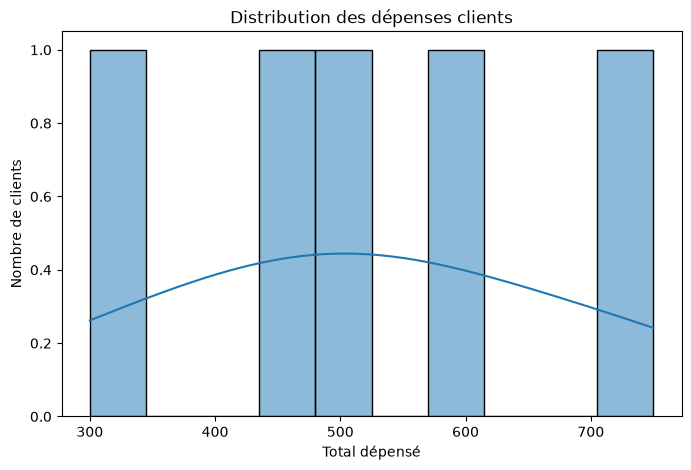

In [20]:
#Distribution des dépenses
plt.figure(figsize=(8,5))

sns.histplot(
    customers["Total_Spent"],
    bins=10,
    kde=True
)

plt.title("Distribution des dépenses clients")
plt.xlabel("Total dépensé")
plt.ylabel("Nombre de clients")
plt.show()

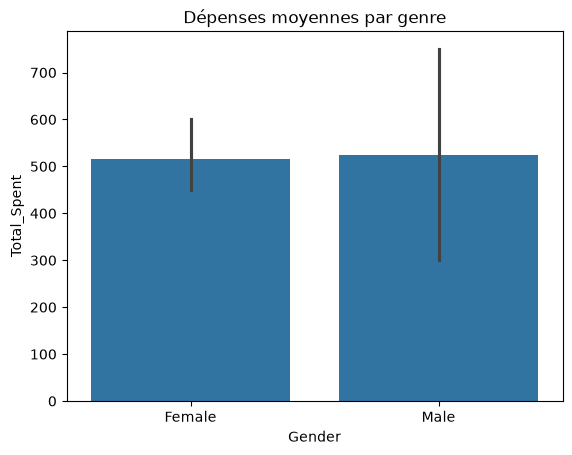

In [21]:
#Dépenses par genre
sns.barplot(
    data=customers,
    x="Gender",
    y="Total_Spent"
)

plt.title("Dépenses moyennes par genre")
plt.show()

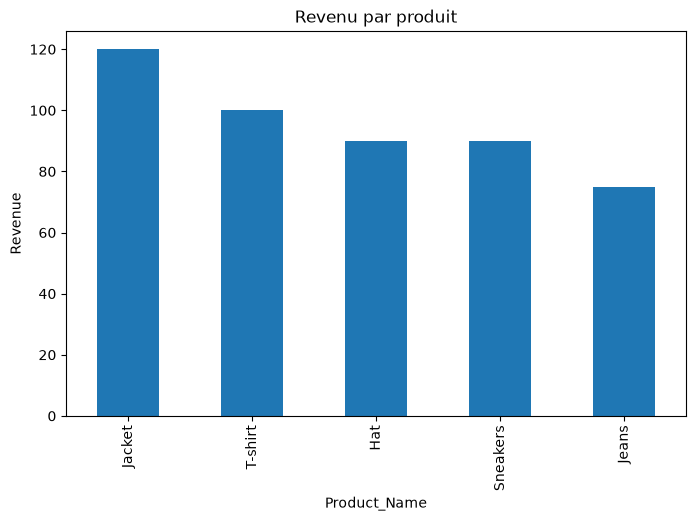

In [22]:
#Revenus par produit
product_revenue = (
    sales_full
    .groupby("Product_Name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenu par produit")
plt.ylabel("Revenue")
plt.show()

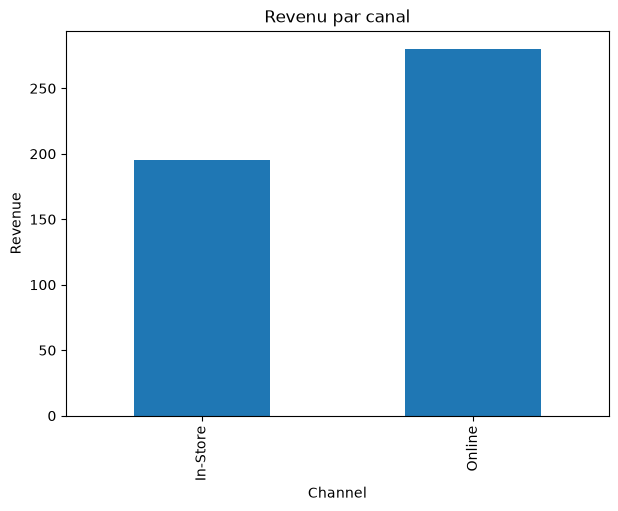

In [23]:
#Revenus par canal
channel_revenue = (
    sales_full
    .groupby("Channel")["Revenue"]
    .sum()
)

channel_revenue.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Revenu par canal")
plt.ylabel("Revenue")
plt.show()